## Phase 3 🎖️
Ames Housing - modeling & prediction

check files name ✔️

In [42]:
import os
os.listdir()

['.config', 'Phase_2_features (1).csv', 'sample_data']

## 📍 import the all required libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler


## Loading dataset feom Phase 1- 2🔃

In [44]:
Phase2_data=pd.read_csv("/content/Phase_2_features (1).csv")

In [45]:
eda_data=Phase2_data.copy()

## EDA 📈

## Histogram📊

Histogram were used to visualize the distribution of numerical features . 'SalePrice' appears right-skewed, indicating most houses have lower prices, while a few have very high values.

array([[<Axes: title={'center': 'SalePrice'}>,
        <Axes: title={'center': 'Gr Liv Area'}>],
       [<Axes: title={'center': 'Lot Area'}>, <Axes: >]], dtype=object)

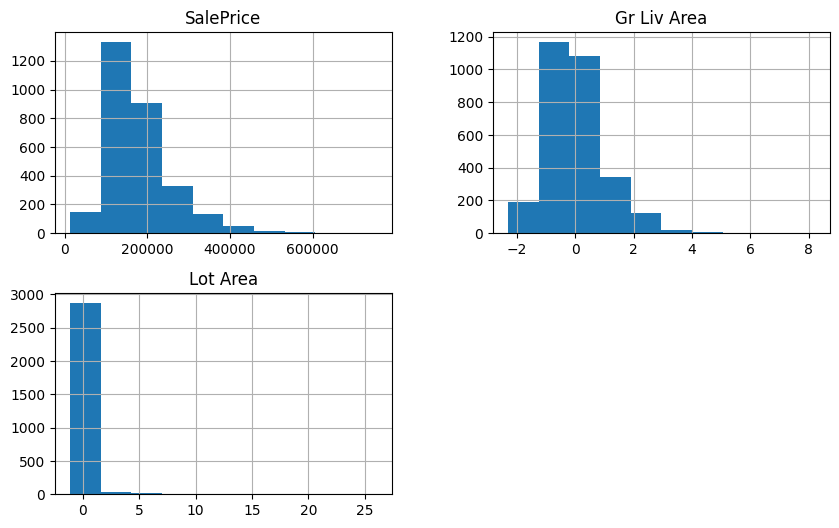

In [46]:
eda_data[['SalePrice','Gr Liv Area','Lot Area']].hist(figsize=(10,6))

##Grouped Bosxplot📤


---



boxplot were used to compare the distribution of house prices across different categories.


---


the plot shows a clear increase in house prices as the overall quality increases, houses with higher quality levels tend to have higher median prices ,

there are also some outliers , especially in higher quality levels ,

insicating that some houses are priced much higher than others within the same category.





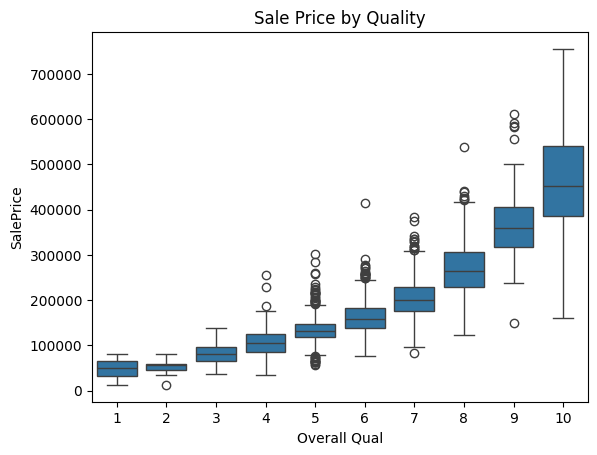

In [64]:
sns.boxplot(x='Overall Qual', y='SalePrice', data=eda_data)
plt.title('Sale Price by Quality')
plt.show()

## Correlation heatmap 🍁📍

the heatmap shows that 'overall quall' and 'Gr Liv Area' have strong positive correlations with 'SalePrice' , indicating they are important factors in determining house prices

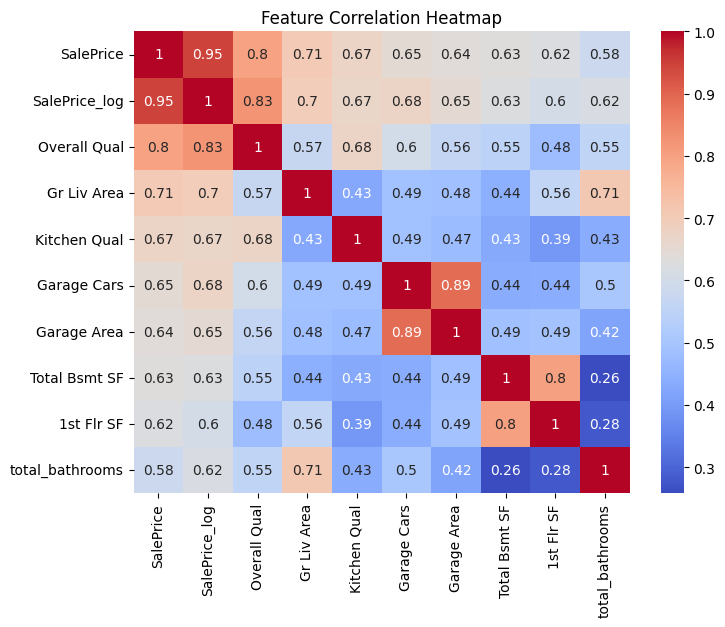

In [62]:
corr = eda_data.corr(numeric_only=True)

top_corr=corr['SalePrice'].abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.heatmap(eda_data[top_corr.index].corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Scatter plot 📊

The scatter plot shows a positive relationship between 'Gr Liv Area' and 'SalePrice', where larger houses tend to have higher prices , it also shows that higher quality houses are generally associated with higher prices .

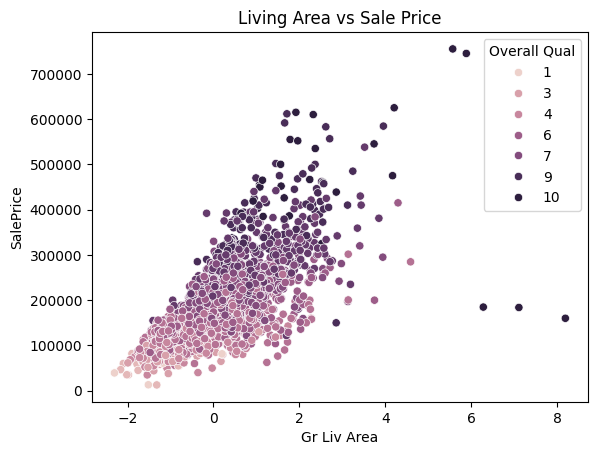

In [61]:
sns.scatterplot(
x='Gr Liv Area',
y='SalePrice',
hue='Overall Qual',
data=eda_data
)
plt.title('Living Area vs Sale Price')
plt.show()

## Groupby Summary 🔢




The averge house prices were calculated for each quality level.the results show that houses with higer quality levels have higher average prices , while lower quality levels have lower prices.

In [50]:
eda_data.groupby('Overall Qual')['SalePrice'].mean().sort_values()

,SalePrice
Overall Qual,
1,48725.000000
2,52325.307692
3,83185.975000
4,106485.097345
5,134752.516364
6,162130.318306
7,205025.760797
8,270913.594286
9,368336.766355


## 🎖️✨ Final Insights



---

The analysis shows that house prices are strongly influenced by features such as overall quality and living area.


---


 higher quality houses and larger living areas tend to have a higher prices .


---


 the visualizaitions also revealed clear relationships between features and the target variable, which helps in understanding the data and building better predictive models.

# Math Basics✖️📐

## mean and standard deviation 🔢


---


The mean and standard deviation of the target varible were calculated manually using Numpy .

In [51]:
y= eda_data['SalePrice'].values

mean=np.mean(y)
std = np.std(y)

print("Mean",mean)
print("Std",std)

Mean 180796.0600682594
Std 79873.05865192253


## Manual Standardization 🎖️

the feature was standardized manually using the formula z- (x-mean) / std and with standardscaler .

In [52]:
col = eda_data['Gr Liv Area'].values

mean= np.mean(col)
std=np.std(col)

z_manual = (col-mean) / std

## Standardization comparison 🔎

i compared the manual standardization with standardscaler by printing sample values .
 the results are very similar , confirming correctnees.

In [53]:
scaler = StandardScaler()
z_scaled= scaler.fit_transform(eda_data[['Gr Liv Area']]).flatten()

print(z_manual[:5])
print(z_scaled[:5])

[ 0.30926506 -1.19442705 -0.33771825  1.20752324  0.25584442]
[ 0.30926506 -1.19442705 -0.33771825  1.20752324  0.25584442]


# cosine similarity✨

i computed the cosine similarity between the highest and lowest records based on sale price .



---


i extract the numerical featuers and applied the cosine similarity formula.


---
this measures how similar the two records are based on their feature values


In [54]:
high = eda_data.loc[eda_data['SalePrice'].idxmax()]
low = eda_data.loc[eda_data['SalePrice'].idxmin()]

num_df =eda_data.select_dtypes(include=[np.number])

high_vec = num_df.loc[high.name].values
low_vec = num_df.loc[low.name].values

cos_sim = np.dot(high_vec,low_vec) / (np.linalg.norm(high_vec) * np.linalg.norm(low_vec))

print("cosine similarity:",cos_sim)

cosine similarity: 0.9999989634396005


# probability Estimate 🤔

in this step :📍


---


i calculated the fraction of high-quality houses Overall Qual >= 8 that have a saleprice above a chosen threshold(median)

In [55]:
high_quality=eda_data[eda_data['Overall Qual']>=8]

threshold = eda_data['SalePrice'].median()

probability = (high_quality['SalePrice']> threshold).mean()

print('Estimated Probability',probability)

Estimated Probability 0.985655737704918


# Bonus🎖️✨

/tmp/ipykernel_2385/540639334.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(bath_data,labels=bath_vals)


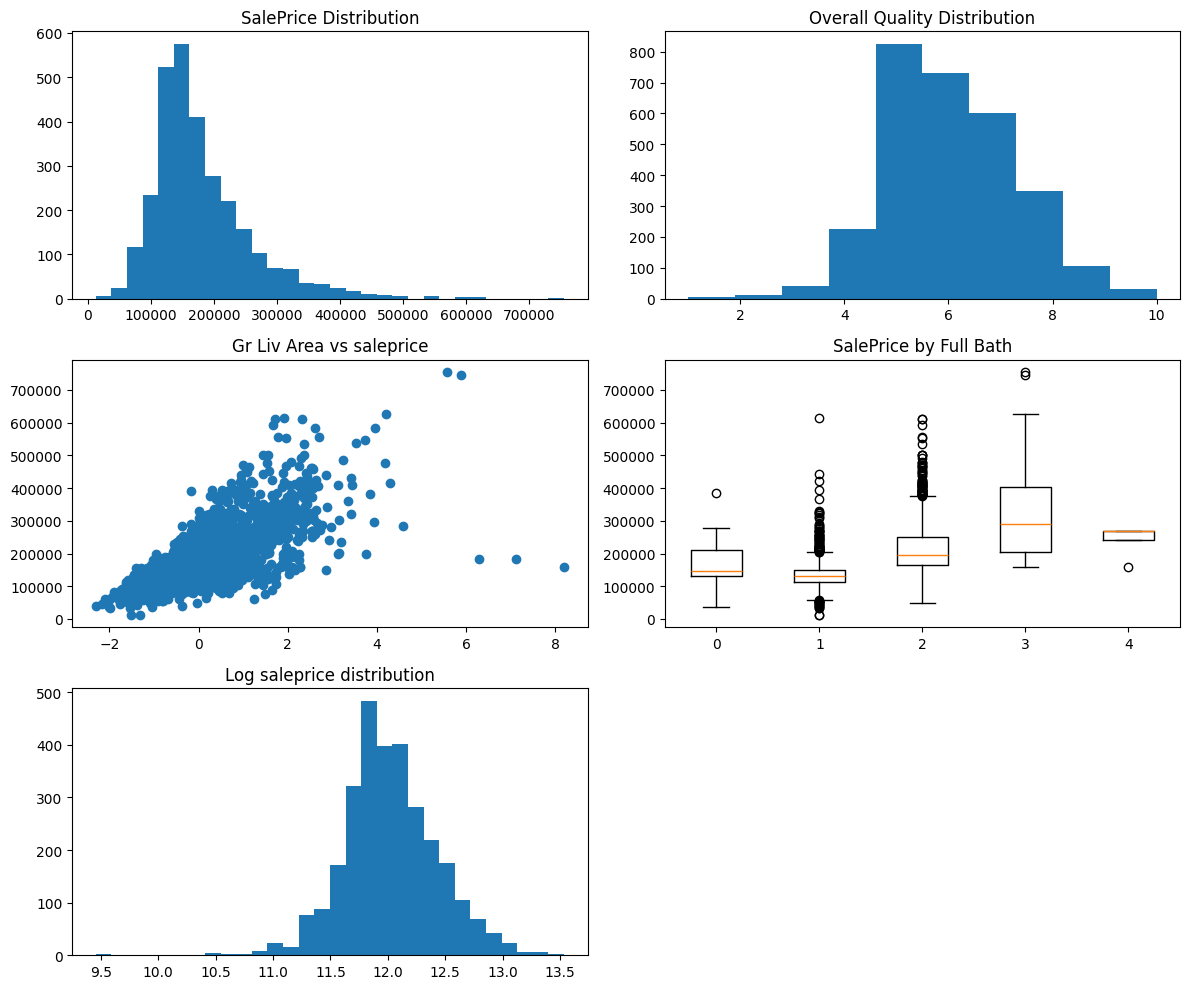

In [60]:
plt.figure(figsize=(12,10))

#🌟 Distribution of saleprice

plt.subplot(3,2,1)
plt.hist(eda_data['SalePrice'],bins=30)
plt.title('SalePrice Distribution')

#🌟Distribution of overall quality

plt.subplot(3,2,2)
plt.hist(eda_data['Overall Qual'],bins=10)
plt.title('Overall Quality Distribution')

#🌟Area vs price

plt.subplot(3,2,3)
plt.scatter(eda_data['Gr Liv Area'],eda_data['SalePrice'])
plt.title('Gr Liv Area vs saleprice')


#🌟price by bathrooms
plt.subplot(3,2,4)
bath_vals=sorted(eda_data['Full Bath'].unique())
bath_data=[eda_data[eda_data['Full Bath']==i]['SalePrice']for i in bath_vals]

plt.boxplot(bath_data,labels=bath_vals)
plt.title('SalePrice by Full Bath')

#🌟log saleprice
plt.subplot(3,2,5)
plt.hist(eda_data['SalePrice_log'],bins=30)
plt.title('Log saleprice distribution')

plt.tight_layout()
plt.show()

# ✨✔️ Data saving

In [57]:
eda_data.to_csv('Eda_Data_3')

# The End 🎖️🔚